/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6520 - loss: 0.6636 - val_accuracy: 0.8182 - val_loss: 0.6039
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7645 - loss: 0.5998 - val_accuracy: 0.8182 - val_loss: 0.5456
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7715 - loss: 0.5549 - val_accuracy: 0.8252 - val_loss: 0.4920
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7680 - loss: 0.5297 - val_accuracy: 0.8252 - val_loss: 0.4518
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7680 - loss: 0.4984 - val_accuracy: 0.8182 - val_loss: 0.4285
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7733 - loss: 0.4877 - val_accuracy: 0.8182 - val_loss: 0.4155
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7698 - loss: 0.4790 - val_accuracy: 0.8182 - val_loss: 0.4071
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7627 - loss: 0.4812 - val_accuracy: 0.8252 - 

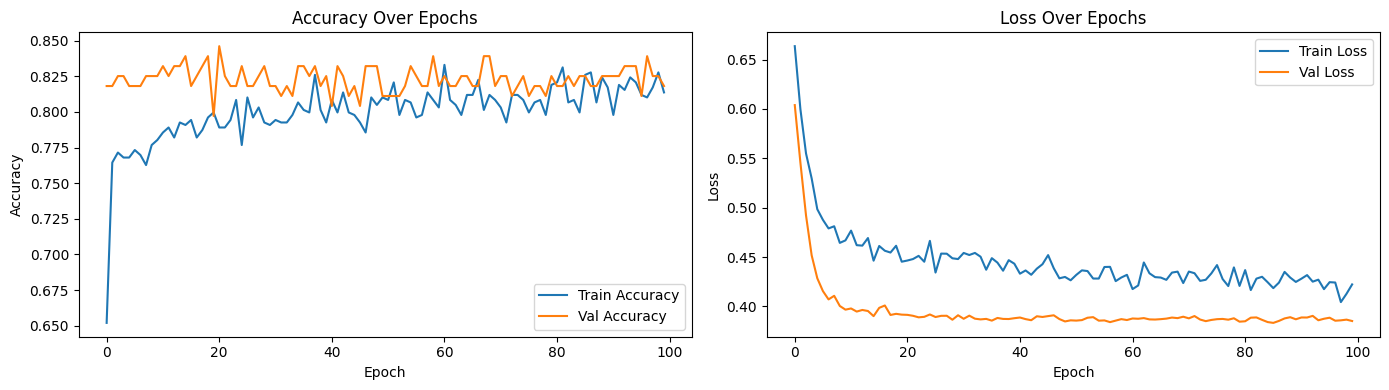

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
👩 1st class female → Survival: 98.2%
👨 3rd class male → Survival: 10.5%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# ── 1. LOAD & CLEAN ────────────────────────────────────────
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'fare']].copy()
df['age']  = df['age'].fillna(df['age'].median())
df['sex']  = df['sex'].map({'male': 0, 'female': 1})

X = df[['pclass', 'sex', 'age', 'fare']].values
y = df['survived'].values

# ── 2. SPLIT ───────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ── 3. SCALE THE DATA ─────────────────────────────────────
# Neural networks need features on similar scales!
# age=38, fare=71 vs pclass=1 → huge difference → confuses the network
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn scale from train
X_test  = scaler.transform(X_test)        # apply SAME scale to test

# ── 4. BUILD THE NEURAL NETWORK ───────────────────────────
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.Dropout(0.3),      # randomly drop 30% of neurons → less overfitting
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1,  activation='sigmoid')  # output: probability 0-1
])

model.summary()  # shows network architecture

# ── 5. COMPILE ────────────────────────────────────────────
model.compile(
    optimizer='adam',                    # weight update algorithm
    loss='binary_crossentropy',          # loss for yes/no problems
    metrics=['accuracy']                 # what to track during training
)

# ── 6. TRAIN ──────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=100,              # 100 passes through training data
    batch_size=32,           # process 32 samples at a time
    validation_split=0.2,    # use 20% of train data to monitor overfitting
    verbose=1                # print progress
)

# ── 7. EVALUATE ───────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  Neural Network Accuracy: {test_acc*100:.1f}%")
print(f"  Random Forest was:       79.3%")
print(f"{'='*40}")

y_pred = (model.predict(X_test) > 0.5).astype(int)
print(classification_report(y_test, y_pred, target_names=['Died','Survived']))

# ── 8. PLOT TRAINING HISTORY ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Accuracy over epochs
ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Accuracy Over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Loss over epochs
ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss Over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.tight_layout()
plt.show()

# ── 9. PREDICT NEW PASSENGERS ────────────────────────────
new_data = pd.DataFrame({
    'pclass': [1,  3],
    'sex':    [1,  0],
    'age':    [25, 35],
    'fare':   [100, 7.25]
})
new_scaled = scaler.transform(new_data)
probs = model.predict(new_scaled)

names = ['👩 1st class female', '👨 3rd class male']
for i, name in enumerate(names):
    print(f"{name} → Survival: {probs[i][0]*100:.1f}%")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Test images:     (10000, 28, 28)
Pixel range:     0 to 255


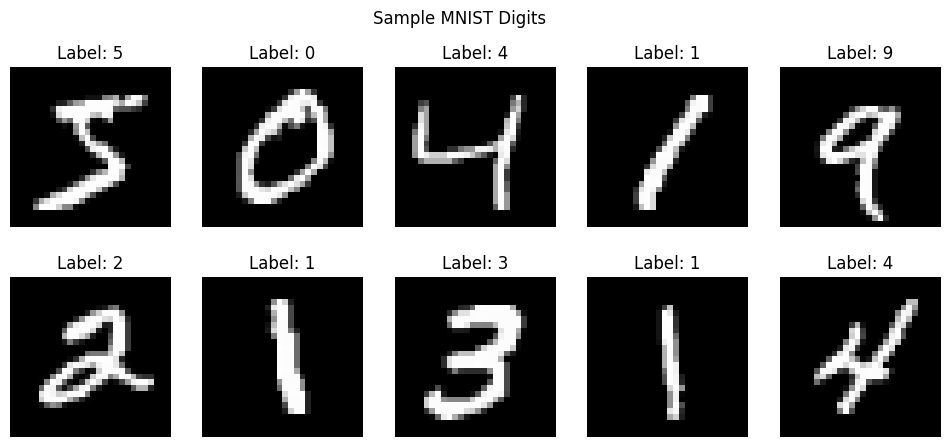


After reshape: (60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.8953 - loss: 0.3391 - val_accuracy: 0.9833 - val_loss: 0.0562
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 54ms/step - accuracy: 0.9690 - loss: 0.1064 - val_accuracy: 0.9850 - val_loss: 0.0449
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 52ms/step - accuracy: 0.9778 - loss: 0.0780 - val_accuracy: 0.9870 - val_loss: 0.0422
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.9830 - loss: 0.0607 - val_accuracy: 0.9907 - val_loss: 0.0375
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 84s 54ms/step - accuracy: 0.9860 - loss: 0.0493 - val_accuracy: 0.9918 - val_loss: 0.0275
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9871 - loss: 0.0433 - val_accuracy: 0.9900 - val_loss: 0.0357
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.9896 - loss: 0.0362 - val_accuracy: 0.9893 - val_loss: 0.0396
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 81s 53ms/step - accuracy: 0.9915 - loss: 0.0296 - 

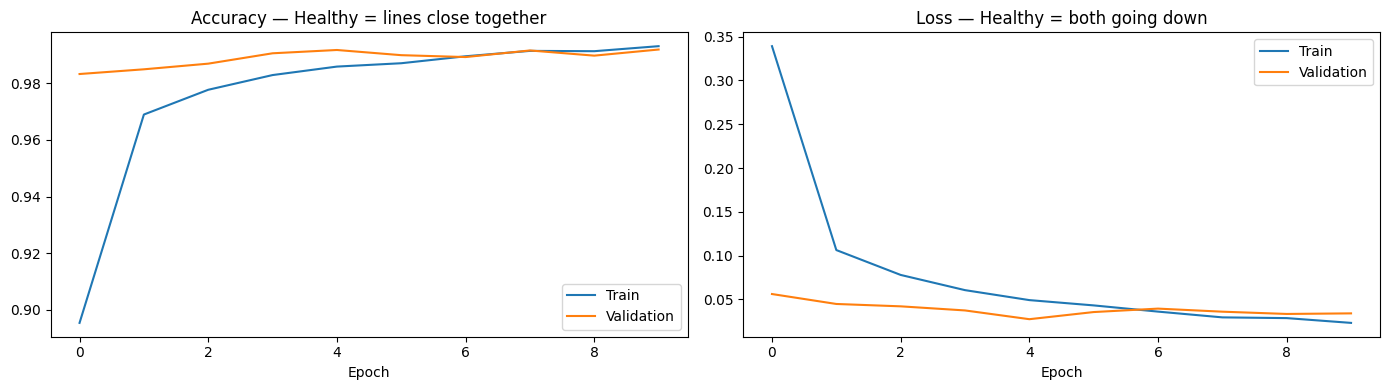

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step


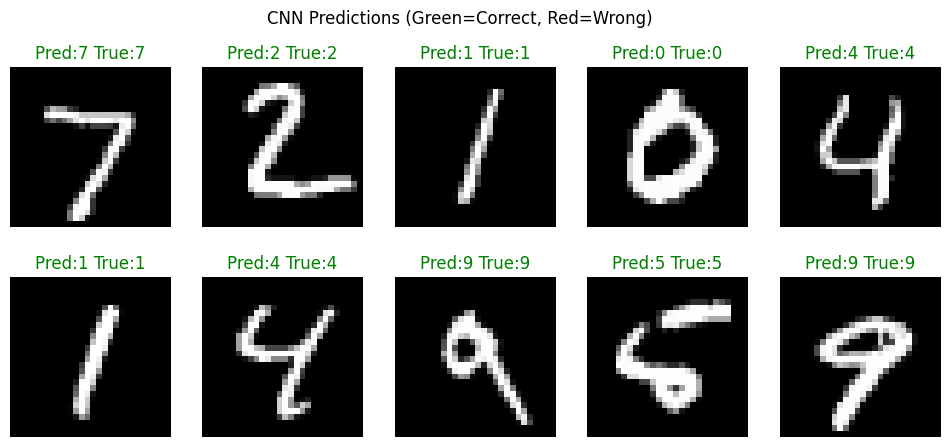


✅ Got all 10 correct!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

# ── 1. LOAD DATA ───────────────────────────────────────────
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"Training images: {X_train.shape}")  # (60000, 28, 28)
print(f"Test images:     {X_test.shape}")   # (10000, 28, 28)
print(f"Pixel range:     {X_train.min()} to {X_train.max()}")

# ── 2. VISUALIZE SOME DIGITS ──────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits")
plt.show()

# ── 3. PREPROCESS ─────────────────────────────────────────
# Normalize pixels from 0-255 to 0-1 (like StandardScaler for images)
X_train = X_train / 255.0
X_test  = X_test  / 255.0

# Reshape: CNN needs (samples, height, width, channels)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

print(f"\nAfter reshape: {X_train.shape}")  # (60000, 28, 28, 1)

# ── 4. BUILD CNN ───────────────────────────────────────────
model = keras.Sequential([
    # Block 1 — detect simple features (edges, curves)
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    # Block 2 — detect complex features (loops, strokes)
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Block 3 — even deeper features
    layers.Conv2D(64, (3,3), activation='relu'),

    # Bridge
    layers.Flatten(),

    # Classifier
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')  # 10 digits!
])

model.summary()

# ── 5. COMPILE & TRAIN ────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',  # for multi-class
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,              # 10 is enough for MNIST!
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# ── 6. EVALUATE ────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  CNN Test Accuracy: {test_acc*100:.2f}%")
print(f"  Target was:        98.00%")
print(f"  {'✅ ACHIEVED!' if test_acc >= 0.98 else '❌ Not yet — try more epochs!'}")
print(f"{'='*40}")

# ── 7. TRAINING CURVES ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy — Healthy = lines close together')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss — Healthy = both going down')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# ── 8. VISUALIZE PREDICTIONS ──────────────────────────────
predictions = model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    correct = predicted_labels[i] == y_test[i]
    color = 'green' if correct else 'red'
    ax.set_title(f"Pred:{predicted_labels[i]} True:{y_test[i]}", color=color)
    ax.axis('off')
plt.suptitle("CNN Predictions (Green=Correct, Red=Wrong)")
plt.show()

# ── 9. WHERE DID IT FAIL? ─────────────────────────────────
wrong_idx = np.where(predicted_labels != y_test[:10])[0]
if len(wrong_idx) == 0:
    print("\n✅ Got all 10 correct!")
else:
    print(f"\n❌ Wrong predictions at indices: {wrong_idx}")


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training reviews:  25000
Test reviews:      25000
Sample label:      1 (1=positive, 0=negative)
Sample review (raw numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]...
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Actual review text:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the

Sentiment: POSITIVE ✅

After padding shape: (25000, 200)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 350ms/step - accuracy: 0.5237 - loss: 0.7054 - val_accuracy: 0.5612 - val_loss: 0.6872
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 355ms/step - accuracy: 0.6179 - loss: 0.6417 - val_accuracy: 0.7780 - val_loss: 0.4915
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 82s 355ms/step - accuracy: 0.6345 - loss: 0.6233 - val_accuracy: 0.6180 - val_loss: 0.6145
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 355ms/step - accuracy: 0.6073 - loss: 0.6523 - val_accuracy: 0.5838 - val_loss: 0.6507
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 55s 348ms/step - accuracy: 0.6295 - loss: 0.6171 - val_accuracy: 0.5892 - val_loss: 0.6564

  LSTM Test Accuracy:  58.98%
  Target:              85%+
  Keep going!


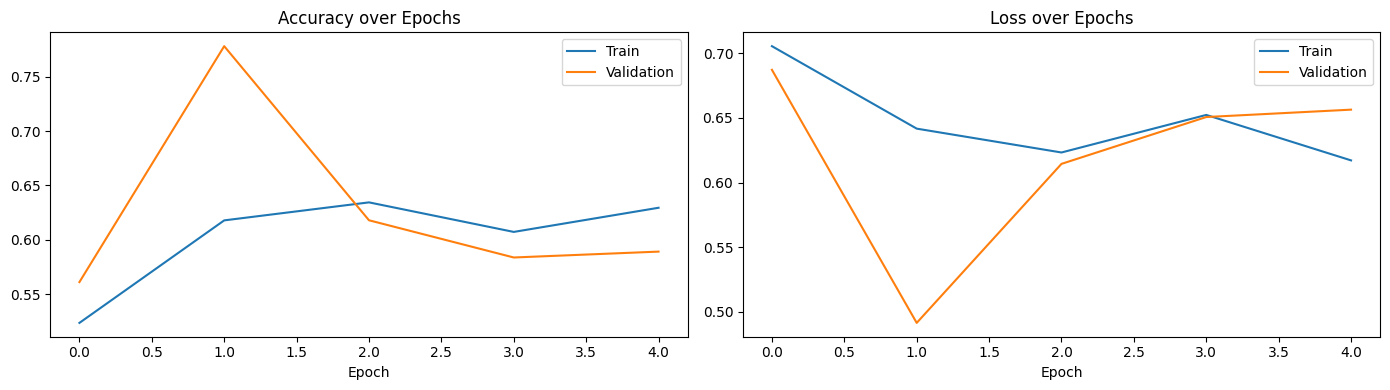


--- Testing on custom reviews ---
Review: 'This movie was absolutely brilliant and amazing...'
Prediction: POSITIVE ✅  (confidence: 62.6%)

Review: 'Terrible film, complete waste of time, awful acting...'
Prediction: NEGATIVE ❌  (confidence: 84.4%)

Review: 'The plot was okay but the ending was disappointing...'
Prediction: NEGATIVE ❌  (confidence: 84.4%)

Review: 'One of the best movies I have ever seen in my life...'
Prediction: POSITIVE ✅  (confidence: 62.6%)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── 1. LOAD IMDB DATA ─────────────────────────────────────
vocab_size  = 10000   # only keep top 10,000 most common words
max_length  = 200     # max words per review

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print(f"Training reviews:  {len(X_train)}")
print(f"Test reviews:      {len(X_test)}")
print(f"Sample label:      {y_train[0]} (1=positive, 0=negative)")
print(f"Sample review (raw numbers): {X_train[0][:10]}...")

# ── 2. DECODE A REVIEW (so we can read it) ────────────────
word_index = imdb.get_word_index()
reverse_index = {v+3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decode_review(encoded):
    return ' '.join([reverse_index.get(i, '?') for i in encoded])

print(f"\nActual review text:")
print(decode_review(X_train[0])[:300])
print(f"\nSentiment: {'POSITIVE ✅' if y_train[0]==1 else 'NEGATIVE ❌'}")

# ── 3. PAD SEQUENCES ──────────────────────────────────────
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test  = pad_sequences(X_test,  maxlen=max_length, padding='post')

print(f"\nAfter padding shape: {X_train.shape}")  # (25000, 200)

# ── 4. BUILD LSTM MODEL ───────────────────────────────────
model = keras.Sequential([
    # Embedding: turns word IDs into dense vectors
    layers.Embedding(vocab_size, 64, input_length=max_length),

    # LSTM: reads sequence, remembers context
    layers.LSTM(64, return_sequences=False),

    layers.Dropout(0.5),

    # Classifier
    layers.Dense(32, activation='relu'),
    layers.Dense(1,  activation='sigmoid')   # positive or negative
])

model.summary()

# ── 5. COMPILE & TRAIN ────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=5,               # 5 is enough for IMDB
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# ── 6. EVALUATE ───────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  LSTM Test Accuracy:  {test_acc*100:.2f}%")
print(f"  Target:              85%+")
print(f"  {'✅ ACHIEVED!' if test_acc >= 0.85 else 'Keep going!'}")
print(f"{'='*40}")

# ── 7. TRAINING CURVES ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# ── 8. TEST ON YOUR OWN REVIEWS ───────────────────────────
def predict_sentiment(review_text):
    word_index = imdb.get_word_index()
    words = review_text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]
    padded  = pad_sequences([encoded], maxlen=max_length, padding='post')
    prob    = model.predict(padded, verbose=0)[0][0]
    label   = "POSITIVE ✅" if prob > 0.5 else "NEGATIVE ❌"
    print(f"Review: '{review_text[:60]}...'")
    print(f"Prediction: {label}  (confidence: {max(prob, 1-prob)*100:.1f}%)\n")

print("\n--- Testing on custom reviews ---")
predict_sentiment("This movie was absolutely brilliant and amazing")
predict_sentiment("Terrible film, complete waste of time, awful acting")
predict_sentiment("The plot was okay but the ending was disappointing")
predict_sentiment("One of the best movies I have ever seen in my life")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,419,905 (5.42 MB)

 Trainable params: 1,419,905 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 803ms/step - accuracy: 0.5494 - loss: 0.6853 - val_accuracy: 0.5892 - val_loss: 0.6582
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 799ms/step - accuracy: 0.6247 - loss: 0.6061 - val_accuracy: 0.6374 - val_loss: 0.5810
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 142s 802ms/step - accuracy: 0.6752 - loss: 0.5144 - val_accuracy: 0.6524 - val_loss: 0.5519
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 797ms/step - accuracy: 0.6948 - loss: 0.4756 - val_accuracy: 0.6480 - val_loss: 0.5660
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 127s 810ms/step - accuracy: 0.7003 - loss: 0.4527 - val_accuracy: 0.6590 - val_loss: 0.5849
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 139s 792ms/step - accuracy: 0.7908 - loss: 0.4245 - val_accuracy: 0.8432 - val_loss: 0.4277
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 125s 797ms/step - accuracy: 0.8324 - loss: 0.3980 - val_accuracy: 0.7286 - val_loss: 0.5793
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 124s 792ms/step - accuracy: 0.8658 -

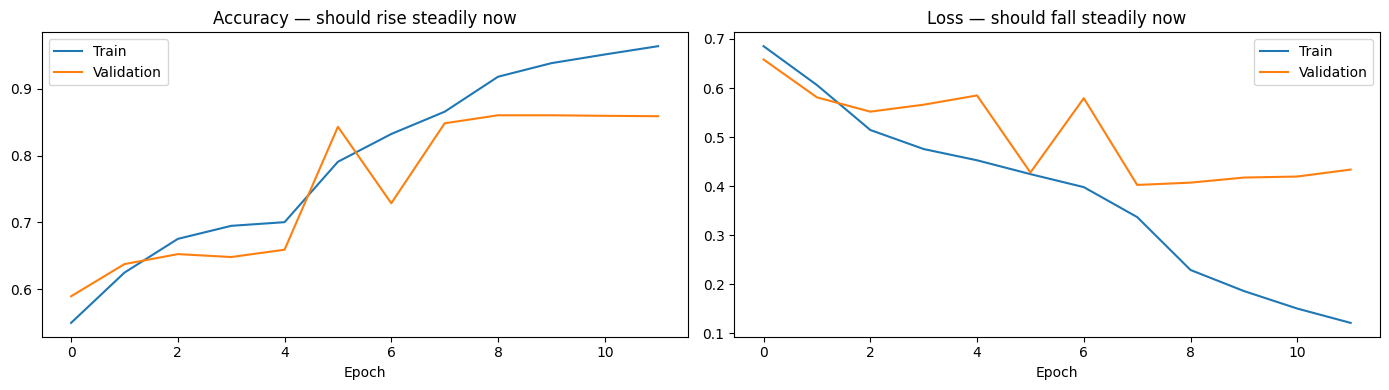


--- Custom Review Tests ---
'This movie was absolutely brilliant and amazing'
  → POSITIVE ✅  (62.8% confident)

'Terrible film complete waste of time awful acting'
  → NEGATIVE ❌  (95.5% confident)

'The plot was okay but the ending was very disappointing'
  → NEGATIVE ❌  (92.0% confident)

'One of the best movies I have ever seen in my life'
  → POSITIVE ✅  (76.0% confident)

'It started great but slowly became incredibly boring'
  → NEGATIVE ❌  (87.2% confident)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── SAME AS BEFORE ─────────────────────────────────────────
vocab_size = 10000
max_length = 200

(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)
X_train = pad_sequences(X_train, maxlen=max_length, padding='post')
X_test  = pad_sequences(X_test,  maxlen=max_length, padding='post')

# ── FIX 1: Add Input layer so model builds properly ────────
model = keras.Sequential([
    keras.Input(shape=(max_length,)),        # ← explicit input shape
    layers.Embedding(vocab_size, 128),       # ← bigger embedding (64→128)
    layers.LSTM(128),                        # ← bigger LSTM (64→128)
    layers.Dropout(0.3),                     # ← less dropout (0.5→0.3)
    layers.Dense(64, activation='relu'),
    layers.Dense(1,  activation='sigmoid')
])

model.summary()   # should now show actual param counts

# ── FIX 2: Lower learning rate → more stable training ──────
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.0005)   # default is 0.001, we halved it

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# ── FIX 3: More epochs + early stopping ────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',   # watch validation accuracy
    patience=3,               # stop if no improvement for 3 epochs
    restore_best_weights=True # revert to best epoch automatically
)

history = model.fit(
    X_train, y_train,
    epochs=15,                # more epochs, early stop will catch it
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],   # ← plug in early stopping
    verbose=1
)

# ── EVALUATE ───────────────────────────────────────────────
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n{'='*40}")
print(f"  LSTM Test Accuracy:  {test_acc*100:.2f}%")
print(f"  Target:              85%+")
print(f"  {'✅ ACHIEVED!' if test_acc >= 0.85 else '🔧 Still tuning...'}")
print(f"{'='*40}")

# ── TRAINING CURVES ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,4))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy — should rise steadily now')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss — should fall steadily now')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

# ── TEST CUSTOM REVIEWS ────────────────────────────────────
def predict_sentiment(review_text):
    word_index = imdb.get_word_index()
    words   = review_text.lower().split()
    encoded = [word_index.get(w, 2) + 3 for w in words]
    padded  = pad_sequences([encoded], maxlen=max_length, padding='post')
    prob    = model.predict(padded, verbose=0)[0][0]
    label   = "POSITIVE ✅" if prob > 0.5 else "NEGATIVE ❌"
    print(f"'{review_text[:65]}'")
    print(f"  → {label}  ({max(prob,1-prob)*100:.1f}% confident)\n")

print("\n--- Custom Review Tests ---")
predict_sentiment("This movie was absolutely brilliant and amazing")
predict_sentiment("Terrible film complete waste of time awful acting")
predict_sentiment("The plot was okay but the ending was very disappointing")
predict_sentiment("One of the best movies I have ever seen in my life")
predict_sentiment("It started great but slowly became incredibly boring")

In [ ]:
# Using HuggingFace — the easiest way to use Transformers
# Run this in Colab:
# !pip install transformers

from transformers import pipeline

# Load a pretrained sentiment model — ONE LINE!
classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

reviews = [
    "This movie was absolutely brilliant and amazing",
    "Terrible film, complete waste of time",
    "The plot was okay but the ending was disappointing",
    "One of the best movies I have ever seen",
    "It started great but slowly became incredibly boring",
    "Not bad, not great, just completely average",  # tricky!
    "So bad it's actually good in a weird way",      # sarcasm!
]

print("=== Transformer Sentiment Analysis ===\n")
results = classifier(reviews)
for review, result in zip(reviews, results):
    emoji = "✅" if result['label'] == 'POSITIVE' else "❌"
    print(f"{emoji} {result['label']} ({result['score']*100:.1f}%)")
    print(f"   '{review}'\n")
at's most relevant:
  trophy → 0.82  ← highest attention
  bag    → 0.11
  fit    → 0.05
  big    → 0.02


SyntaxError: unterminated string literal (detected at line 29) (3354695702.py, line 29)

In [ ]:
# First run this in a Colab cell:
# !pip install transformers -q

from transformers import pipeline

classifier = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

reviews = [
    "This movie was absolutely brilliant and amazing",
    "Terrible film, complete waste of time, awful acting",
    "The plot was okay but the ending was disappointing",
    "One of the best movies I have ever seen in my life",
    "It started great but slowly became incredibly boring",
    "Not bad, not great, just completely average",
    "So bad it's actually good in a weird way",        # sarcasm!
    "I wanted to love this but it let me down badly",  # tricky!
]

print("=" * 55)
print("  LSTM (your model)  vs  DistilBERT (Transformer)")
print("=" * 55)

lstm_results = [
    ("POSITIVE", 62.8),
    ("NEGATIVE", 95.5),
    ("NEGATIVE", 92.0),
    ("POSITIVE", 76.0),
    ("NEGATIVE", 87.2),
    ("?", 0),   # didn't test these
    ("?", 0),
    ("?", 0),
]

results = classifier(reviews)
for i, (review, result) in enumerate(zip(reviews, results)):
    bert_label = result['label']
    bert_conf  = result['score'] * 100
    lstm_label, lstm_conf = lstm_results[i]

    bert_emoji = "✅" if bert_label == "POSITIVE" else "❌"
    print(f"\n'{review[:50]}'")
    print(f"  LSTM:      {lstm_label} ({lstm_conf:.1f}%)")
    print(f"  DistilBERT:{bert_emoji} {bert_label} ({bert_conf:.1f}%)")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

  LSTM (your model)  vs  DistilBERT (Transformer)

'This movie was absolutely brilliant and amazing'
  LSTM:      POSITIVE (62.8%)
  DistilBERT:✅ POSITIVE (100.0%)

'Terrible film, complete waste of time, awful actin'
  LSTM:      NEGATIVE (95.5%)
  DistilBERT:❌ NEGATIVE (100.0%)

'The plot was okay but the ending was disappointing'
  LSTM:      NEGATIVE (92.0%)
  DistilBERT:❌ NEGATIVE (99.9%)

'One of the best movies I have ever seen in my life'
  LSTM:      POSITIVE (76.0%)
  DistilBERT:✅ POSITIVE (100.0%)

'It started great but slowly became incredibly bori'
  LSTM:      NEGATIVE (87.2%)
  DistilBERT:❌ NEGATIVE (99.9%)

'Not bad, not great, just completely average'
  LSTM:      ? (0.0%)
  DistilBERT:❌ NEGATIVE (98.1%)

'So bad it's actually good in a weird way'
  LSTM:      ? (0.0%)
  DistilBERT:✅ POSITIVE (99.3%)

'I wanted to love this but it let me down badly'
  LSTM:      ? (0.0%)
  DistilBERT:❌ NEGATIVE (99.9%)


Total articles: 44898
Fake: 23481 | Real: 21417

Columns: ['title', 'text', 'subject', 'date', 'label']

Sample fake headline:
   Donald Trump Sends Out Embarrassing New Year’s Eve Message; This is Disturbing

Sample real headline:
  As U.S. budget fight looms, Republicans flip their fiscal script


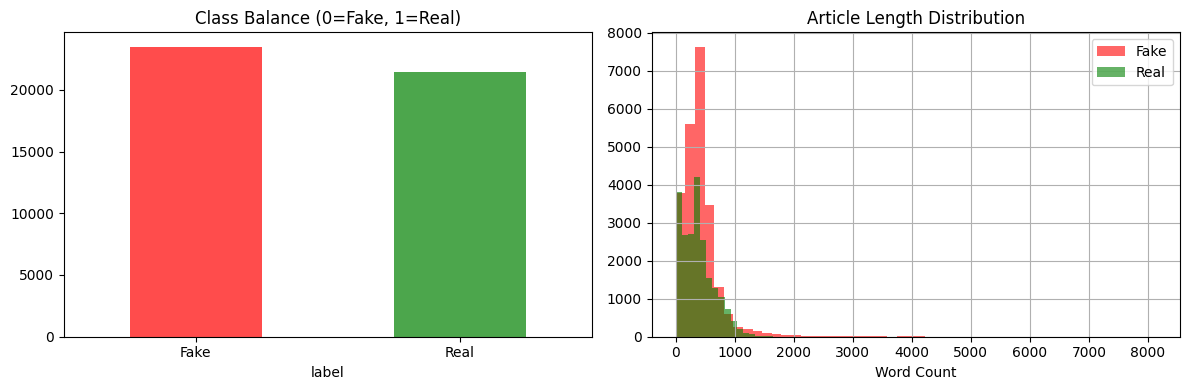


Train: 35918 | Test: 8980

  STAGE 1: TF-IDF + Logistic Regression
Feature matrix shape: (35918, 50000)

Accuracy: 98.81%
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4696
        Real       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Top words indicating FAKE news:
  'video': -9.729
  'just': -7.041
  'hillary': -5.782
  'gop': -5.514
  'president trump': -5.437
  'read': -5.218
  'image': -5.217
  'featured image': -5.080
  'featured': -5.033
  'obama': -4.845
  'watch': -4.811
  'america': -4.618
  'mr': -4.593
  'com': -4.043
  'like': -4.016

Top words indicating REAL news:
  'reuters': 22.141
  'said': 17.740
  'washington reuters': 9.348
  'president donald': 5.419
  'republican': 5.190
  'washington': 5.163
  'wednesday': 5.152
  'reuters president': 4.825
  'tuesda

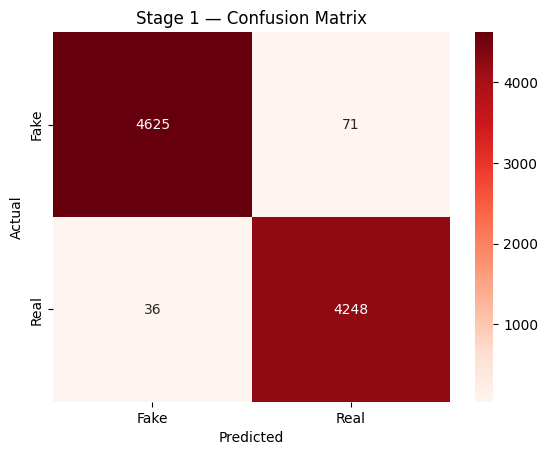


--- Testing Custom Headlines ---
Headline: 'Scientists discover new treatment for cancer'
  → FAKE ❌  (65.9% confident)

Headline: 'SHOCKING: President secretly reptilian alien revealed'
  → FAKE ❌  (94.0% confident)

Headline: 'Federal Reserve raises interest rates by 0.25%'
  → FAKE ❌  (61.2% confident)

Headline: 'BREAKING: Celebrity confirms they are secret lizard person'
  → FAKE ❌  (95.7% confident)



(np.int64(0), np.float64(95.70313326999694))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ── 1. LOAD & COMBINE DATA ────────────────────────────────
fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')

fake['label'] = 0   # 0 = fake
real['label'] = 1   # 1 = real

df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Total articles: {len(df)}")
print(f"Fake: {len(fake)} | Real: {len(real)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample fake headline:\n  {fake['title'].iloc[0]}")
print(f"\nSample real headline:\n  {real['title'].iloc[0]}")

# ── 2. EXPLORE ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class balance
df['label'].value_counts().plot(kind='bar', ax=axes[0],
    color=['red','green'], alpha=0.7)
axes[0].set_title('Class Balance (0=Fake, 1=Real)')
axes[0].set_xticklabels(['Fake', 'Real'], rotation=0)

# Article length distribution
df['text_length'] = df['text'].str.split().str.len()
df[df['label']==0]['text_length'].hist(ax=axes[1], alpha=0.6,
    label='Fake', color='red', bins=50)
df[df['label']==1]['text_length'].hist(ax=axes[1], alpha=0.6,
    label='Real', color='green', bins=50)
axes[1].set_title('Article Length Distribution')
axes[1].legend()
axes[1].set_xlabel('Word Count')
plt.tight_layout()
plt.show()

# ── 3. PREPARE TEXT ───────────────────────────────────────
# Combine title + text for richer features
df['content'] = df['title'] + ' ' + df['text']

X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ── 4. STAGE 1 — TF-IDF + LOGISTIC REGRESSION ────────────
print("\n" + "="*50)
print("  STAGE 1: TF-IDF + Logistic Regression")
print("="*50)

# TF-IDF: converts text to numerical features
# TF = how often word appears in document
# IDF = how rare the word is across all documents
# Common words (the, a, is) get low scores
# Rare meaningful words get high scores
tfidf = TfidfVectorizer(
    max_features=50000,    # keep top 50k words
    ngram_range=(1, 2),    # single words AND pairs ("fake news", "breaking news")
    stop_words='english'   # remove "the", "a", "is" etc
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

# Train
lr_model = LogisticRegression(max_iter=1000, C=1.0)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"\nAccuracy: {lr_acc*100:.2f}%")
print(classification_report(y_test, lr_pred,
      target_names=['Fake','Real']))

# ── 5. MOST IMPORTANT WORDS ───────────────────────────────
feature_names = tfidf.get_feature_names_out()
coefficients  = lr_model.coef_[0]

top_fake_idx = coefficients.argsort()[:15]
top_real_idx = coefficients.argsort()[-15:][::-1]

print("\nTop words indicating FAKE news:")
for idx in top_fake_idx:
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.3f}")

print("\nTop words indicating REAL news:")
for idx in top_real_idx:
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.3f}")

# ── 6. CONFUSION MATRIX ───────────────────────────────────
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Fake','Real'],
            yticklabels=['Fake','Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Stage 1 — Confusion Matrix')
plt.show()

# ── 7. STAGE 2 — PREDICT YOUR OWN HEADLINES ──────────────
def predict_headline(headline, verbose=True):
    vec   = tfidf.transform([headline])
    pred  = lr_model.predict(vec)[0]
    prob  = lr_model.predict_proba(vec)[0]
    label = "REAL ✅" if pred == 1 else "FAKE ❌"
    conf  = max(prob) * 100
    if verbose:
        print(f"Headline: '{headline[:70]}'")
        print(f"  → {label}  ({conf:.1f}% confident)\n")
    return pred, conf

print("\n--- Testing Custom Headlines ---")
predict_headline("Scientists discover new treatment for cancer")
predict_headline("SHOCKING: President secretly reptilian alien revealed")
predict_headline("Federal Reserve raises interest rates by 0.25%")
predict_headline("BREAKING: Celebrity confirms they are secret lizard person")


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# ── 1. RELOAD DATA ────────────────────────────────────────
fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')
fake['label'] = 0
real['label'] = 1
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# ── 2. CLEAN TEXT — remove source artifacts ───────────────
def clean_text(text):
    # Remove Reuters dateline e.g. "WASHINGTON (Reuters) -"
    text = re.sub(r'^.*?\(Reuters\)\s*-?\s*', '', str(text))
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove special characters, keep letters/spaces
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Lowercase
    text = text.lower().strip()
    return text

print("Cleaning text...")
df['clean_text'] = df['text'].apply(clean_text)
df['clean_title'] = df['title'].apply(clean_text)
df['content'] = df['clean_title'] + ' ' + df['clean_text']

# Check Reuters removed
sample = df[df['label']==1]['content'].iloc[0]
print(f"\nCleaned real article start:\n{sample[:200]}")

# ── 3. SPLIT ──────────────────────────────────────────────
X = df['content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── 4. TF-IDF + LOGISTIC REGRESSION ──────────────────────
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english'
)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f"\n{'='*50}")
print(f"  After cleaning accuracy: {lr_acc*100:.2f}%")
print(f"  Before cleaning was:     98.81%")
print(f"{'='*50}")
print(classification_report(y_test, lr_pred,
      target_names=['Fake','Real']))

# ── 5. TOP WORDS AFTER CLEANING ───────────────────────────
feature_names  = tfidf.get_feature_names_out()
coefficients   = lr_model.coef_[0]

top_fake_idx = coefficients.argsort()[:15]
top_real_idx = coefficients.argsort()[-15:][::-1]

print("Top FAKE indicators (after cleaning):")
for idx in top_fake_idx:
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.3f}")

print("\nTop REAL indicators (after cleaning):")
for idx in top_real_idx:
    print(f"  '{feature_names[idx]}': {coefficients[idx]:.3f}")

# ── 6. PREDICT CUSTOM HEADLINES ───────────────────────────
def predict_headline(headline):
    cleaned = clean_text(headline)
    vec     = tfidf.transform([cleaned])
    pred    = lr_model.predict(vec)[0]
    prob    = lr_model.predict_proba(vec)[0]
    label   = "REAL ✅" if pred == 1 else "FAKE ❌"
    conf    = max(prob) * 100
    print(f"'{headline[:70]}'")
    print(f"  → {label}  ({conf:.1f}% confident)\n")

print("\n--- Custom Headlines (after fixing leakage) ---")
predict_headline("Scientists discover new treatment for cancer")
predict_headline("SHOCKING: President secretly reptilian alien revealed")
predict_headline("Federal Reserve raises interest rates by 0.25%")
predict_headline("BREAKING: Celebrity confirms they are secret lizard person")
predict_headline("Senate passes bipartisan infrastructure bill")
predict_headline("You wont believe what Obama did with this ONE trick")


Cleaning text...

Cleaned real article start:
trump drops steve bannon from national security council us president donald trump removed his chief strategist steve bannon from the national security council on wednesday reversing his controversial 

  After cleaning accuracy: 98.52%
  Before cleaning was:     98.81%
              precision    recall  f1-score   support

        Fake       0.99      0.98      0.99      4696
        Real       0.98      0.99      0.98      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Top FAKE indicators (after cleaning):
  'video': -11.452
  'just': -7.653
  'image': -5.915
  'gop': -5.730
  'obama': -5.700
  'president trump': -5.442
  'hillary': -5.412
  'america': -5.356
  'don': -5.247
  'like': -4.488
  'didn': -4.479
  'mr': -4.310
  'doesn': -4.112
  'watch': -4.106
  've': -4.101

Top REAL indicators (after cleaning):
  'said'

In [ ]:
!pip install transformers datasets -q

In [ ]:
# Run this first in a new cell:
# !pip install transformers datasets -q

import numpy as np
import pandas as pd
import re
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments
)
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# ── 1. RELOAD & CLEAN DATA ────────────────────────────────
fake = pd.read_csv('Fake.csv')
real = pd.read_csv('True.csv')
fake['label'] = 0
real['label'] = 1
df = pd.concat([fake, real], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

def clean_text(text):
    text = re.sub(r'^.*?\(Reuters\)\s*-?\s*', '', str(text))
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text.lower().strip()

df['content'] = df['title'].apply(clean_text)  # title only — faster!

# ── 2. USE SMALL SAMPLE FOR SPEED ─────────────────────────
# Full dataset takes hours — 5000 samples trains in ~10 mins on Colab GPU
df_small = df.groupby('label').apply(
    lambda x: x.sample(2500, random_state=42)
).reset_index(drop=True)

print(f"Training on {len(df_small)} samples (balanced)")
print(f"Fake: {(df_small.label==0).sum()} | Real: {(df_small.label==1).sum()}")

X_train, X_test, y_train, y_test = train_test_split(
    df_small['content'].tolist(),
    df_small['label'].tolist(),
    test_size=0.2, random_state=42, stratify=df_small['label']
)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

# ── 3. TOKENIZE ───────────────────────────────────────────
print("\nLoading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(X_train, truncation=True,
                             padding=True, max_length=128)
test_encodings  = tokenizer(X_test,  truncation=True,
                             padding=True, max_length=128)

# ── 4. CREATE PYTORCH DATASET ─────────────────────────────
class NewsDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx])
                for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = NewsDataset(train_encodings, y_train)
test_dataset  = NewsDataset(test_encodings,  y_test)

# ── 5. LOAD PRETRAINED MODEL ──────────────────────────────
print("Loading DistilBERT model...")
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# ── 6. DEFINE METRICS ─────────────────────────────────────
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc}

# ── 7. TRAINING ARGUMENTS ─────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = './results',
    num_train_epochs            = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size  = 32,
    warmup_steps                = 100,
    weight_decay                = 0.01,
    eval_strategy               = 'epoch',   # ← fixed
    save_strategy               = 'epoch',
    load_best_model_at_end      = True,
    logging_steps               = 50,
    report_to                   = 'none'
)

# ── 8. TRAIN ──────────────────────────────────────────────
print("\nFine-tuning DistilBERT (needs GPU — check Runtime > T4 GPU)")
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = test_dataset,
    compute_metrics = compute_metrics,
)
trainer.train()

# ── 9. EVALUATE ───────────────────────────────────────────
results = trainer.evaluate()
print(f"\n{'='*50}")
print(f"  TF-IDF + LR accuracy:    98.52%")
print(f"  DistilBERT accuracy:     {results['eval_accuracy']*100:.2f}%")
print(f"{'='*50}")

# Full classification report
preds_output = trainer.predict(test_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
print(classification_report(y_test, y_pred,
      target_names=['Fake','Real']))

# ── 10. PREDICT CUSTOM HEADLINES ──────────────────────────
def predict_bert(headline):
    cleaned = clean_text(headline)
    inputs  = tokenizer(cleaned, return_tensors='pt',
                        truncation=True, padding=True,
                        max_length=128)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)[0]
    pred  = torch.argmax(probs).item()
    conf  = probs[pred].item() * 100
    label = "REAL ✅" if pred == 1 else "FAKE ❌"
    print(f"'{headline[:70]}'")
    print(f"  → {label}  ({conf:.1f}% confident)\n")

print("\n--- DistilBERT Custom Headlines ---")
predict_bert("Scientists discover new treatment for cancer")
predict_bert("SHOCKING: President secretly reptilian alien revealed")
predict_bert("Federal Reserve raises interest rates by 0.25%")
predict_bert("Senate passes bipartisan infrastructure bill")
predict_bert("You wont believe what Obama did with this ONE trick")
predict_bert("Scientists discover new treatment for cancer") # was wrong before!


/tmp/ipykernel_319/4246096611.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_small = df.groupby('label').apply(


Training on 5000 samples (balanced)
Fake: 2500 | Real: 2500
Train: 4000 | Test: 1000

Loading DistilBERT tokenizer...
Loading DistilBERT model...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Fine-tuning DistilBERT (needs GPU — check Runtime > T4 GPU)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



  TF-IDF + LR accuracy:    98.52%
  DistilBERT accuracy:     94.60%


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

        Fake       0.97      0.92      0.94       500
        Real       0.92      0.97      0.95       500

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.95      0.95      0.95      1000


--- DistilBERT Custom Headlines ---
'Scientists discover new treatment for cancer'
  → REAL ✅  (80.9% confident)

'SHOCKING: President secretly reptilian alien revealed'
  → FAKE ❌  (96.5% confident)

'Federal Reserve raises interest rates by 0.25%'
  → REAL ✅  (96.0% confident)

'Senate passes bipartisan infrastructure bill'
  → REAL ✅  (98.7% confident)

'You wont believe what Obama did with this ONE trick'
  → FAKE ❌  (95.8% confident)

'Scientists discover new treatment for cancer'
  → REAL ✅  (80.9% confident)

